In [1]:
# !pip install pauliopt

In [2]:
import numpy as np
from src.envs.generators import Circuits
# from numpy import random as rng
rng = np.random.RandomState(1337)

In [3]:
qubits = 10
steps = 1000

In [4]:
from collections import OrderedDict
from itertools import combinations

from src.envs.diag_t import DiagT

In [5]:
rng.choice(range(20), size=6)

array([ 8,  7,  7, 18, 18,  8])

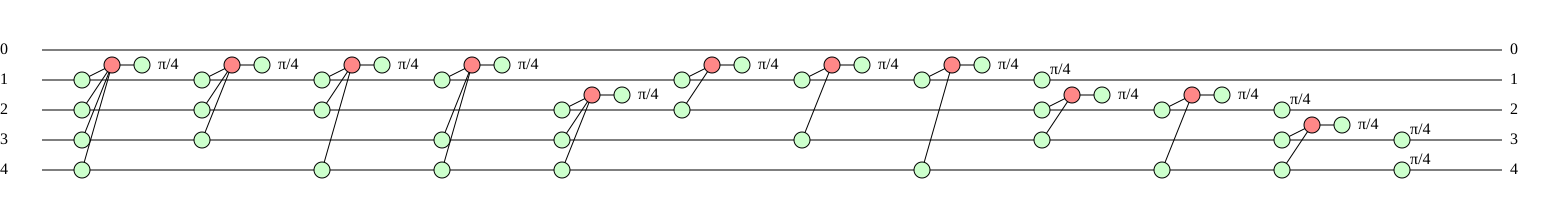

In [6]:
c = DiagT(5, ignore_cliffords=True).add_gadget(6, (1,2,3)).spider_nest((1,2,3,4))
c

In [7]:
c.is_id()

True

In [8]:
c = DiagT(5, ignore_cliffords=True).spider_nest((1,2,3,4)).spider_nest((0,1,2,3))
# c.spider_nest((1,2,3,4), k=7)
c.is_id()

True

In [9]:
c = DiagT(6, ignore_cliffords=True).spider_nest((1,2,3,4,0)).spider_nest((0,1,2,3)).add_gadget(2, (1, 2))
# c.spider_nest((1,2,3,4), k=7)
c.is_id()

True

<Axes: title={'center': 'Random walk: 10 qubits'}, xlabel='Steps', ylabel='n gadgets'>

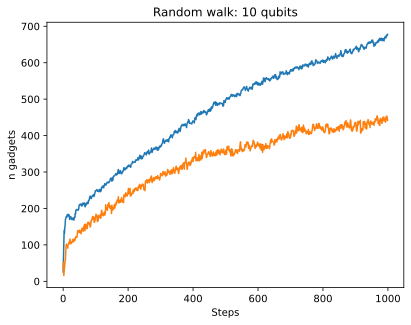

In [10]:
# sample = gen.generate(rng)

steps = 1000

from pauliopt import phase as pauliopt

from pandas import Series

def random_walk_track(circ, steps, rng):
    sizes = []
    qubits = circ.n_qubits
    t = pauliopt.pi / 4
    orig_circ = circ.cloned()
    for _ in range(steps):
        size = rng.randint(4, min(circ.n_qubits, 8) + 1)
        qubits = rng.choice(range(circ.n_qubits), size=size, replace=False).tolist()
        times = rng.randint(1, 8)
        circ = circ.spider_nest(qubits, k=1)
        sizes.append(circ.n_gadgets)
    return sizes
# print(len(sample[0].gadgets))
# print(len(sample[1].gadgets))

c1 = DiagT(qubits, ignore_cliffords=False)
c2 = DiagT(qubits, ignore_cliffords=True)

Series(random_walk_track(c1, steps, rng)).plot(xlabel='Steps', ylabel='n gadgets', title=f'Random walk: {qubits} qubits')
Series(random_walk_track(c2, steps, rng)).plot(xlabel='Steps', ylabel='n gadgets')

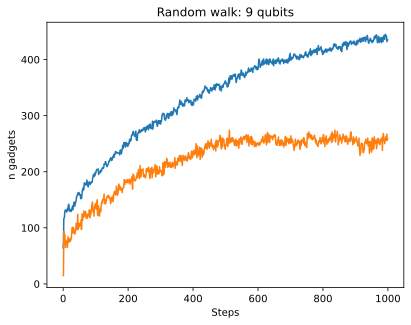

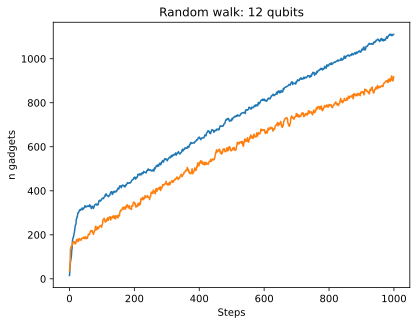

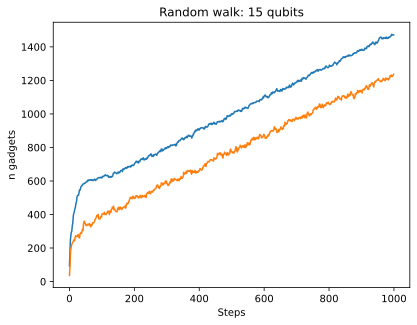

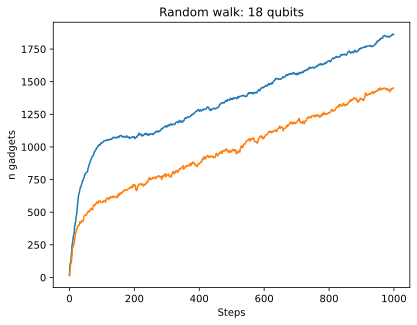

In [13]:
import matplotlib.pyplot as plt
for qubits in range(9, 21, 3):
    c1 = DiagT(qubits, ignore_cliffords=False)
    c2 = DiagT(qubits, ignore_cliffords=True)
    
    Series(random_walk_track(c1, steps, rng)).plot(xlabel='Steps', ylabel='n gadgets', title=f'Random walk: {qubits} qubits')
    Series(random_walk_track(c2, steps, rng)).plot(xlabel='Steps', ylabel='n gadgets')
    plt.show()